In [1]:
import uproot,json,os
import ROOT
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import mplhep as hep
from scipy import stats
import itertools

In [2]:
import awkward as ak

In [3]:
hep.style.use("CMS")
matplotlib.rcParams['figure.figsize'] = (6, 5.5)
matplotlib.rcParams['figure.dpi'] = 100

In [4]:
def getXProjections(x_arr,y_arr,nMinProj=-1):
    xU = np.unique(x_arr)
    xVal     =[]     
    xProj    =[]
    xProj_err=[]
    for x in xU:
        mask= x_arr==x
        if np.sum(mask) < nMinProj:
            continue
        avg = np.average( y_arr[mask] )
        std = np.std( y_arr[mask] )
        xProj.append(avg)
        xProj_err.append(std)
        xVal.append(x)
    return {'x':np.array(xVal) , 'projection' : np.array(xProj) , 'stdev' : np.array(xProj_err) }

In [5]:
compressionNTTMap=np.array([0,0,0,0,0,0,1,1,1,1,1,2,2,2,2,2,3,3,3,3,3,
                         4,4,4,4,4,5,5,5,5,5,6,6,6,6,6,7,7,7,7,7,8
                         ,8,8,8,8,9,9,9,9,9,10,10,10,10,10,
                         11,11,11,11,11,12,12,12,12,12,13,13,13,13,13,
                         14,14,14,14,14,15,15,15,15,15,16,16,16,16,16,
                         17,17,17,17,17,18,18,18,18,18,19,19,19,19,19,
                         20,20,20,20,20,21,21,21,21,21,22,22,22,22,22,
                         23,23,23,23,23,24,24,24,24,24,25,25,25,25,25,
                         26,26,26,26,26,27,27,27,27,27,28,28,28,28,28,
                         29,29,29,29,29,30,30,30,30,30,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,])

compressionRawEtMap=np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,1, 1, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 
                              7, 7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 16, 17, 17, 
                              17, 18, 18, 18, 19, 19, 19, 20, 20, 20, 21,21, 21, 22, 22, 22, 22, 23, 23, 23, 23, 24, 
                              24, 24, 24, 25, 25, 25, 25, 25, 26, 26, 26,26, 26, 26, 27, 27, 27, 27, 27, 27, 27, 28, 
                              28, 28, 28, 28, 28, 28, 28, 28, 28, 29, 29,29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 
                              29, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30,30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 
                              30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,30, 30, 30, 30, 30, 30, 31, 31, 31, 31, 31, 
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31,31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31,
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31,
                              31, 31, 31, 31, 31, 31, 31, 31]
                            )

compressionEtaMap=np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 
                            2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 
                            3, 3, 3, 3, 3, 3, 3, 3]
)

In [ ]:
isolationFname='LUT_0p7_17_29.txt'

with open(isolationFname) as f:
    txt=f.readlines()

idx=0
isoLUT=[]
for l in txt:
    if len(l) <2 : continue
    if l.startswith('#') : continue
    l=l.split('#')[0].strip().split()
    index=int(l[0])
    if index!=idx:
        print(f"LUT not proper ! for expected index {idx} , the value obtained is {index}")
        raise ValueError
    isoLUT.append(int(l[1]))
    idx+=1
isoLUT=np.array(isoLUT)        

In [ ]:
prefix='results/IsoDerivation/zs_scheme/def/validation/'
fname='/home/aravind/Documents/dumpX/L1Ntuple_9.root'
fname='/home/aravind/Documents/dumpX/L1NTuple_EZB123_2025C_dcs260525__slimmed.root'

In [8]:
saveFig=False

In [9]:
file= uproot.open(fname)

tree=file['l1UpgradeEmuTree/L1UpgradeTree/L1Upgrade']

FileNotFoundError: [Errno 2] No such file or directory: '/home/aravind/Documents/dumpX/L1NTuple_EZB123_2025C_dcs260525__slimmed.root'

In [ ]:
branches=[]
for i in tree.keys():
    if 'tau' in i :
        branches.append(i)

In [ ]:
print(branches)

['tauEt', 'tauEta', 'tauPhi', 'tauIEt', 'tauIEta', 'tauIPhi', 'tauIso', 'tauBx', 'tauTowerIPhi', 'tauTowerIEta', 'tauRawEt', 'tauIsoEt', 'tauNTT', 'tauHasEM', 'tauIsMerged', 'tauHwQual']


In [ ]:
data=tree.arrays(branches)

In [ ]:
N_EVTS=len(data)

In [ ]:
dataStore={}

In [ ]:
counts=ak.num(data.tauRawEt)

intRawEt = np.array(ak.flatten( data.tauRawEt))

intRawEt[ intRawEt > 255 ] =255
dataStore['l1tEmuRawEt'] = intRawEt
dataStore['compressedRawEt']=compressionRawEtMap[intRawEt]
data['compressedRawEt']=ak.unflatten(dataStore['compressedRawEt'],counts)

In [ ]:
counts=ak.num(data.tauNTT)

intNTT = np.array(ak.flatten( data.tauNTT))

intNTT[ intNTT > 1023 ] =1023
dataStore['counts']=counts
dataStore['l1tEmuNTT']=intNTT
dataStore['compressedNTT']=compressionNTTMap[intNTT]
data['compressedNTT']=ak.unflatten(dataStore['compressedNTT'],counts)

In [ ]:
counts=ak.num(data.tauIEta)

intIEta = np.array(ak.flatten( data.tauIEta))
# intIEta[ intIEta > 15 ] =15
dataStore['l1tEmuTowerIEta']=intIEta
cbis=np.abs(intIEta)
cbis[cbis>31]=31
dataStore['compressedIEta']=compressionEtaMap[cbis]
data['compressedIEta']=ak.unflatten(dataStore['compressedIEta'],counts)

In [ ]:
num=ak.num(data.tauIEta)

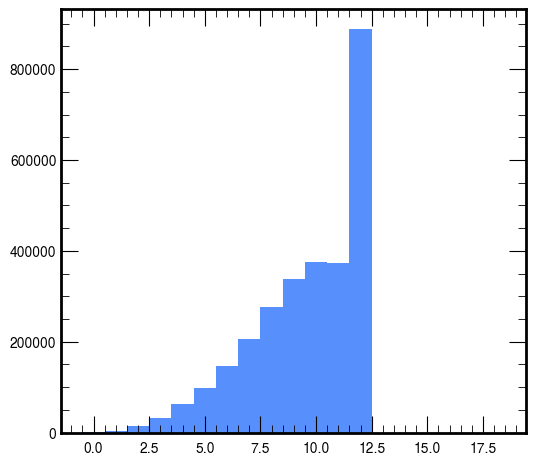

In [ ]:
_=plt.hist(num,np.arange(20)-0.5)

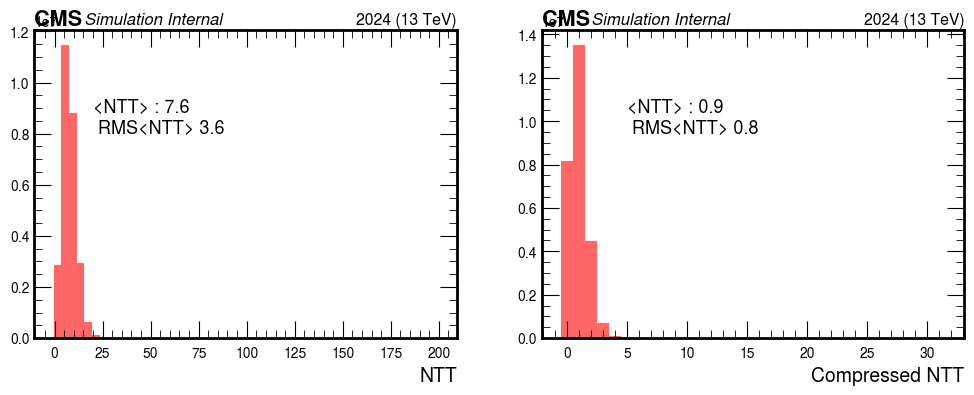

In [ ]:
gMask=dataStore['l1tEmuNTT']>0
intNTT=np.array(dataStore['l1tEmuNTT'][gMask],dtype=int)

compressedNTT=dataStore['compressedNTT']

f,ax=plt.subplots(1,2,figsize=(12,4))

_=ax[0].hist(dataStore['l1tEmuNTT'][gMask],np.arange(-0.5,200.0,4),alpha=0.6,color='r')
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
mu=np.average(dataStore['l1tEmuNTT'][gMask])
stdev=np.std(dataStore['l1tEmuNTT'][gMask])
ax[0].text(20,max(_[0])*0.7,f"<NTT> : {mu:.1f}\n RMS<NTT> {stdev:.1f}",fontsize=13)
ax[0].set_xlabel('NTT',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])

_=ax[1].hist(compressedNTT,np.arange(-0.5,32.0,1),alpha=0.6,color='r')
mu=np.average(compressedNTT)
stdev=np.std(compressedNTT)
ax[1].text(5,max(_[0])*0.7,f"<NTT> : {mu:.1f}\n RMS<NTT> {stdev:.1f}",fontsize=13)
ax[1].set_xlabel('Compressed NTT',fontsize=14)
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[1])
if saveFig:
    plt.savefig(f'{prefix}/compressedNTT.png',bbox_inches='tight')
# plt.semilogy()

In [ ]:
dataStore['l1tEmuIsoEt']=ak.flatten(data['tauIsoEt'])

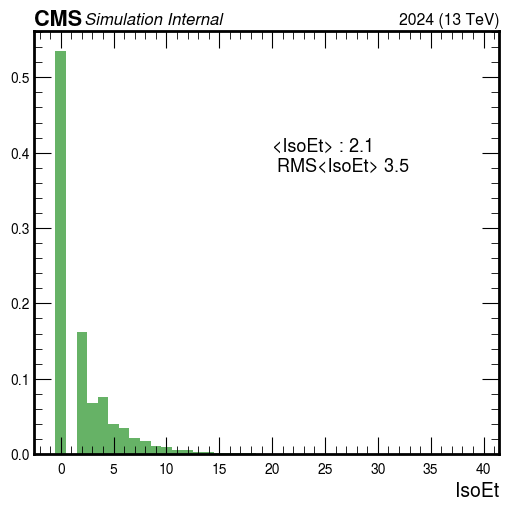

In [ ]:
_=plt.hist(dataStore['l1tEmuIsoEt'],np.arange(-0.5,40.0,1),alpha=0.6,color='g',density=True)
mu=np.average(dataStore['l1tEmuIsoEt'])
stdev=np.std(dataStore['l1tEmuIsoEt'])
plt.text(20,max(_[0])*0.7,f"<IsoEt> : {mu:.1f}\n RMS<IsoEt> {stdev:.1f}",fontsize=13)
plt.xlabel('IsoEt',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024')
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
if saveFig:
    plt.savefig(f'{prefix}/IsoEt.png',bbox_inches='tight')

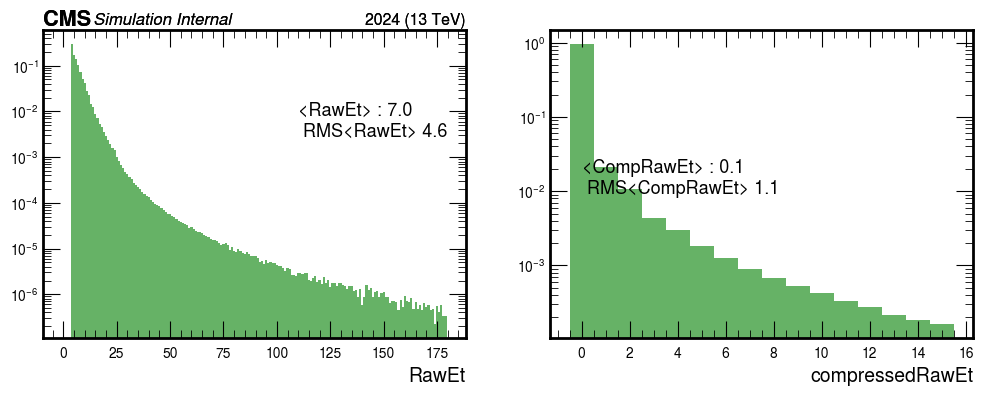

In [ ]:
f,ax=plt.subplots(1,2,figsize=(12,4))

_=ax[0].hist(dataStore['l1tEmuRawEt'],np.arange(-0.5,180.0,1),alpha=0.6,color='g',density=True)
mu=np.average(dataStore['l1tEmuRawEt'])
stdev=np.std(dataStore['l1tEmuRawEt'])
ax[0].text(110,max(_[0])*0.01,f"<RawEt> : {mu:.1f}\n RMS<RawEt> {stdev:.1f}",fontsize=13)
ax[0].set_xlabel('RawEt',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])


_=ax[1].hist(dataStore['compressedRawEt'],np.arange(-0.5,16.0,1),alpha=0.6,color='g',density=True)
mu=np.average(dataStore['compressedRawEt'])
stdev=np.std(dataStore['compressedRawEt'])
ax[1].text(0,max(_[0])*0.01,f"<CompRawEt> : {mu:.1f}\n RMS<CompRawEt> {stdev:.1f}",fontsize=13)
ax[1].set_xlabel('compressedRawEt',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])
ax[0].semilogy()
ax[1].semilogy()
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
if saveFig:
    plt.savefig(f'{prefix}/compressedRawEt.png',bbox_inches='tight')

In [ ]:
dataStore['l1tEmuTowerIEta']

array([48,  4,  6, ...,  9,  9,  3], dtype=int16)

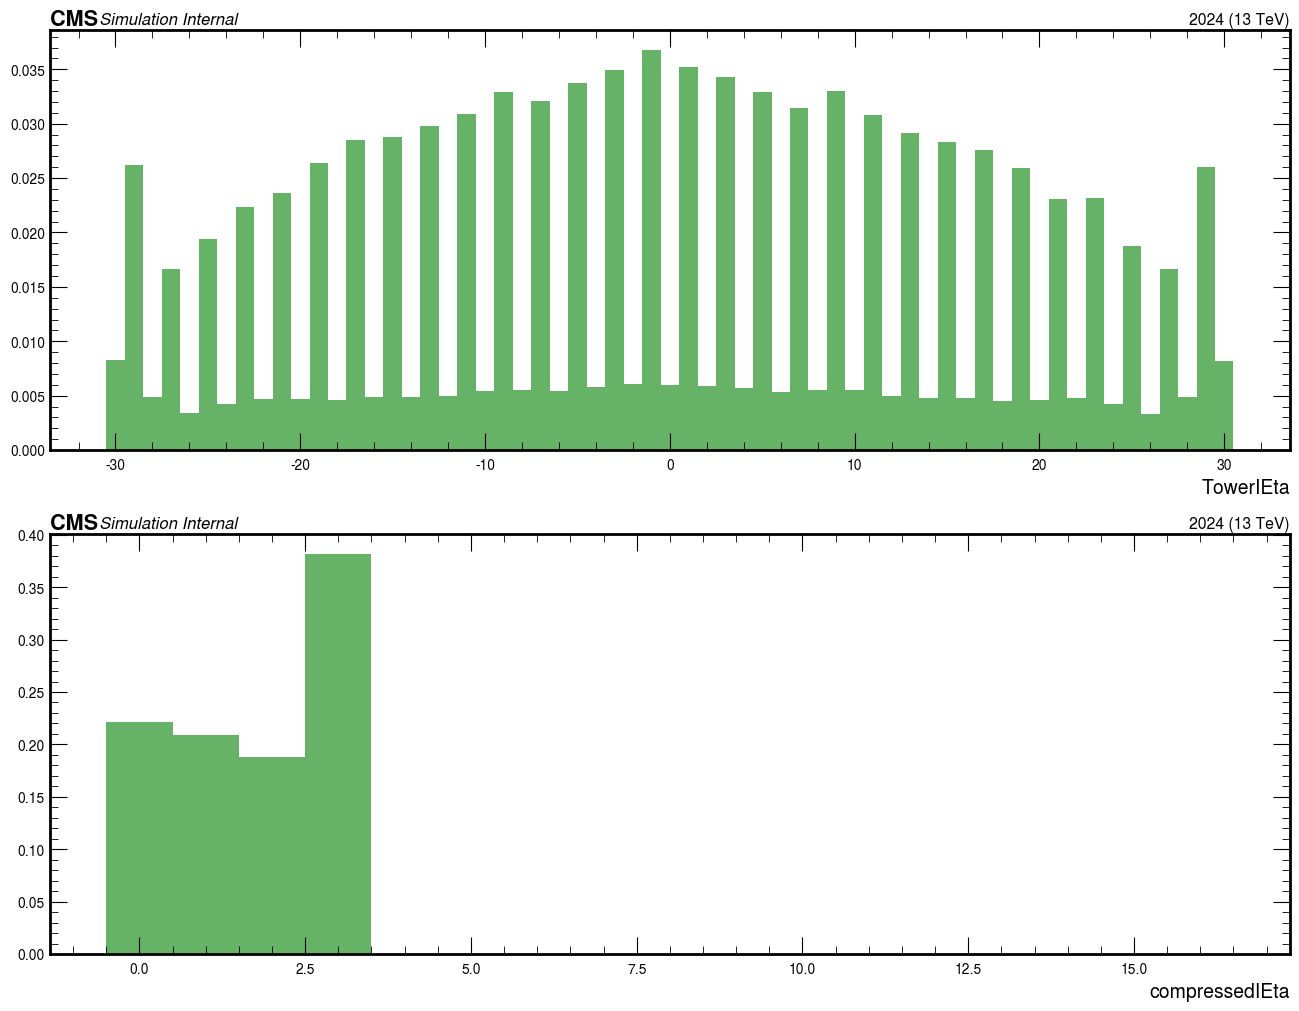

In [ ]:
f,ax=plt.subplots(2,1,figsize=(16,12))
mask= np.abs(dataStore['l1tEmuTowerIEta']) < 32
_=ax[0].hist(dataStore['l1tEmuTowerIEta'][mask],np.arange(-30.5,31.0,1),alpha=0.6,color='g',density=True)
# mu=np.average(dataStore['l1tEmuEta'])
# stdev=np.std(dataStore['l1tEmuEta'])
# plt.text(110,max(_[0])*0.7,f"<l1tEmuEta> : {mu:.1f}\n RMS<l1tEmuEta> {stdev:.1f}",fontsize=13)
ax[0].set_xlabel('TowerIEta',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])

_=ax[1].hist(dataStore['compressedIEta'][mask],np.arange(-0.5,17.0,1),alpha=0.6,color='g',density=True)
# mu=np.average(dataStore['l1tEmuEta'])
# stdev=np.std(dataStore['l1tEmuEta'])
# plt.text(110,max(_[0])*0.7,f"<l1tEmuEta> : {mu:.1f}\n RMS<l1tEmuEta> {stdev:.1f}",fontsize=13)
ax[1].set_xlabel('compressedIEta',fontsize=14)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[1])
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
if saveFig:
    plt.savefig(f'{prefix}/compressedIEta.png',bbox_inches='tight')

In [ ]:
isolationFname='LUT.txt'

with open(isolationFname) as f:
    txt=f.readlines()

idx=0
isoLUT=[]
for l in txt:
    if len(l) <2 : continue
    if l.startswith('#') : continue
    l=l.split('#')[0].strip().split()
    index=int(l[0])
    if index!=idx:
        print(f"LUT not proper ! for expected index {idx} , the value obtained is {index}")
        raise ValueError
    isoLUT.append(int(l[1]))
    idx+=1
isoLUT=np.array(isoLUT)        

In [ ]:
ieta=dataStore['compressedIEta']
iet =dataStore['compressedRawEt']
intt=dataStore['compressedNTT']

lut_index = ieta<<10 | iet <<5 | intt

In [ ]:
isolation_thr = isoLUT[lut_index]

In [ ]:
dataStore['isolation_bit'] = dataStore['l1tEmuIsoEt'] < isolation_thr 

In [ ]:
data['is_iso'] = ak.unflatten(dataStore['isolation_bit'],dataStore['counts'])

In [ ]:
iso_leg = data['is_iso'] & ( data['Et'] > 10.0 )

In [ ]:
rates=[]

In [ ]:
ak.sum(ak.sum(iso_leg,axis=1) > 0)

np.int64(1493726)

In [ ]:
def singleIEtSeed(data,iet):
    seed_cond=  data['tauEt'] >= iet
    return ak.sum(seed_cond,axis=1) > 0

def singleIEtIsoSeed(data,iet):
    seed_cond = data['is_iso'] & (data['tauEt'] >= iet)
    return ak.sum(seed_cond,axis=1) > 0


def doubleIEtSeed(data,iet1,iet2):
    ltau1 = data['tauEt'] >= iet1
    leg2 = data['tauEt'] >= iet2
    nSeedPass= ( ak.sum(leg1,axis=1) > 0) & ( ak.sum(leg2,axis=1) > 1)
    return nSeedPass

def doubleIEtSingleIsoSeed(data,iet1,iet2):
    leg1 = (data['tauEt'] >= iet1) & data['is_iso']
    leg2 = (data['tauEt'] >= iet2) 
    nSeedPass= ( ak.sum(leg1,axis=1) > 0) & ( ak.sum(leg2,axis=1) > 1)
    return nSeedPass

def doubleIEtDoubelIsoSeed(data,iet1,iet2):
    leg1 = (data['tauEt'] >= iet1) & data['is_iso']
    leg2 = (data['tauEt'] >= iet2) & data['is_iso']
    nSeedPass= ( ak.sum(leg1,axis=1) > 0) & ( ak.sum(leg2,axis=1) > 1)
    return nSeedPass

all_seeds_to_probe={}
all_seeds_to_probe['Single']={}
all_seeds_to_probe['Double']={}

all_seeds_to_probe['Single']['SigleEG']=singleIEtSeed
all_seeds_to_probe['Single']['SingleIsoEG']=singleIEtIsoSeed

all_seeds_to_probe['Double']['DoubleEG']=doubleIEtSeed
all_seeds_to_probe['Double']['DoubleEGSingleIso']=doubleIEtSingleIsoSeed
all_seeds_to_probe['Double']['DoubleIsoEG']=doubleIEtDoubelIsoSeed

In [ ]:
leg1 = data['tauEt'] >= 8
leg2 = data['tauEt'] >= 8

In [ ]:
nSeedPass= ( ak.sum(leg1,axis=1) > 0) & ( ak.sum(leg2,axis=1) > 1)

In [ ]:
np.where(nSeedPass)

(<Array [0, 1, 3, 9, ..., 2816325, 2816330, 2816331] type='1243759 * int64'>,)

In [ ]:
idx=2
print(np.array(leg1[idx]))
print(np.array(leg2[idx]))
print(nSeedPass[idx])
print(np.array(data[idx]['tauEt']))

[ True False False False False]
[ True False False False False]
False
[16.500002  4.000001  3.000001  3.000001  3.000001]


In [ ]:
rate_scale_factor=26.5*1e3/N_EVTS

In [ ]:
rateStore={}

In [ ]:
rateStore['METADATA']={
    'RATE_SCALE' : rate_scale_factor
}

In [ ]:
selector=all_seeds_to_probe['Single']['SigleEG']
rateDict={'threashold':[],'rate':[],'rate_err':[],'pass':[],'n_events':int(N_EVTS)}
et_thr=[]
rates=[]
for i in range(81):
    print(f"\rDoing Et = {i}   ",end="")
    seed_events = selector(data,i)
    pass_count=int(ak.sum(seed_events))
    rateDict['pass'].append(pass_count)
    rateDict['rate'].append(pass_count*rate_scale_factor)
    rateDict['rate_err'].append(pass_count**0.5*rate_scale_factor)
    rateDict['threashold'].append(i)
rateStore['SingleEG_Inclusive']=rateDict

Doing Et = 80   

In [ ]:
rateStore.keys()

dict_keys(['SingleEG_SingleIso', 'DoubleEG_Inclusive', 'DoubleEG_DoubleIsoEG', 'DoubleEGXandXp10_SingleIsoXplus10', 'SingleEG_Inclusive'])

In [ ]:
selector=all_seeds_to_probe['Single']['SingleIsoEG']
rateDict={'threashold':[],'rate':[],'rate_err':[],'pass':[],'n_events':int(N_EVTS)}
et_thr=[]
rates=[]
for i in range(81):
    print(f"\rDoing Et = {i}   ",end="")
    seed_events = selector(data,i)
    pass_count=int(ak.sum(seed_events))
    rateDict['pass'].append(pass_count)
    rateDict['rate'].append(pass_count*rate_scale_factor)
    rateDict['rate_err'].append(pass_count**0.5*rate_scale_factor)
    rateDict['threashold'].append(i)
rateStore['SingleEG_SingleIso']=rateDict

Doing Et = 80   

In [ ]:
selector=all_seeds_to_probe['Double']['DoubleEG']
rateDict={'threashold':[],'rate':[],'rate_err':[],'pass':[],'n_events':int(N_EVTS)}
et_thr=[]
rates=[]
for i in range(81):
    print(f"\rDoing Et = {i}   ",end="")
    seed_events = selector(data,i,i)
    pass_count=int(ak.sum(seed_events))
    rateDict['pass'].append(pass_count)
    rateDict['rate'].append(pass_count*rate_scale_factor)
    rateDict['rate_err'].append(pass_count**0.5*rate_scale_factor)
    rateDict['threashold'].append(i)
rateStore['DoubleEG_Inclusive']=rateDict

Doing Et = 80   

In [ ]:
selector=all_seeds_to_probe['Double']['DoubleIsoEG']
rateDict={'threashold':[],'rate':[],'rate_err':[],'pass':[],'n_events':int(N_EVTS)}
et_thr=[]
rates=[]
for i in range(81):
    print(f"\rDoing Et = {i}   ",end="")
    seed_events = selector(data,i,i)
    pass_count=int(ak.sum(seed_events))
    rateDict['pass'].append(pass_count)
    rateDict['rate'].append(pass_count*rate_scale_factor)
    rateDict['rate_err'].append(pass_count**0.5*rate_scale_factor)
    rateDict['threashold'].append(i)
rateStore['DoubleEG_DoubleIsoEG']=rateDict

Doing Et = 80   

In [ ]:
selector=all_seeds_to_probe['Double']['DoubleEGSingleIso']
rateDict={'threashold':[],'rate':[],'rate_err':[],'pass':[],'n_events':int(N_EVTS)}
et_thr=[]
rates=[]
for i in range(81):
    print(f"\rDoing Et = {i}   ",end="")
    seed_events = selector(data,i+10,i)
    pass_count=int(ak.sum(seed_events))
    rateDict['pass'].append(pass_count)
    rateDict['rate'].append(pass_count*rate_scale_factor)
    rateDict['rate_err'].append(pass_count**0.5*rate_scale_factor)
    rateDict['threashold'].append(i)
rateStore['DoubleEGXandXp10_SingleIsoXplus10']=rateDict

Doing Et = 80   

In [ ]:
# rateStore={}

# for selector_ky in selectorStore:
#     print("Making rates for  ",selector_ky)
#     selector=selectorStore[selector_ky]
#     rateDict={'threashold':[],'rate':[],'rate_err':[],'pass':[],'n_events':int(N_EVTS)}
#     et_thr=[]
#     rates=[]
#     for i in range(81):
#         print(f"\rDoing Et = {i}   ",end="")
#         seed_events = selector(data,i)
#         pass_count=int(ak.sum(seed_events))
#         rateDict['pass'].append(pass_count)
#         rateDict['rate'].append(pass_count*rate_scale_factor)
#         rateDict['rate_err'].append(pass_count**0.5*rate_scale_factor)
#         rateDict['threashold'].append(i)
#     rateStore[selector_ky]=rateDict
#     print()

In [ ]:
from functools import partial

In [ ]:
y= lambda x,y : doubleIEtSeed(x,y,y+10)

In [ ]:
np.sum(doubleIEtSeed(data,10,10+10))

3

In [ ]:
np.sum(y(data,10))

3

In [ ]:
selectorStore={}
selectorStore['SingleEG_Inclusive'] = singleIEtSeed
selectorStore['SingleIsoEG'] = singleIEtIsoSeed
selectorStore['DoubleEG_Inclusive'] = lambda d,e1: doubleIEtSeed(d,e1,e1)
selectorStore['DoubleIsoEG'] = lambda d,e1: doubleIEtDoubelIsoSeed(d,e1,e1) 
selectorStore['DoubleEGXandXp10_SingleIsoXplus10'] = lambda d,e1: doubleIEtSingleIsoSeed(d,e1+10,e1)

SingleEG_SingleIso
DoubleEG_Inclusive
DoubleEG_DoubleIsoEG
DoubleEGXandXp10_SingleIsoXplus10
SingleEG_Inclusive


(exptext: Custom Text(0.001, 1, 'CMS'),
 expsuffix: Custom Text(0.001, 1.005, 'Internal'),
 supptext: Custom Text(1.012, 1, ''))

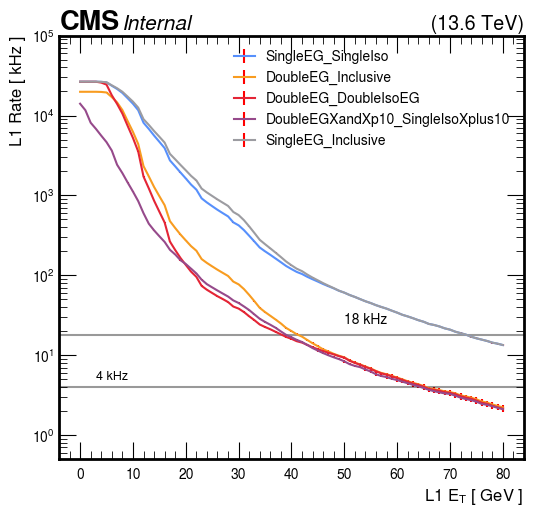

In [ ]:
for ky in rateStore:
    print(ky)
    plt.errorbar(rateStore[ky]['threashold'],
                 rateStore[ky]['rate'],
                 rateStore[ky]['rate_err'],
                 ecolor='r',
                 label=ky
                )
plt.semilogy()
plt.legend(fontsize=10)
plt.ylim([5e-1,1e5])
plt.axhline(18.0,color='k',alpha=0.4)
plt.text(50.0,25,"18 kHz",fontsize=10)
plt.axhline(4.0,color='k',alpha=0.4)
plt.text(3.0,5,"4 kHz",fontsize=9)
plt.ylabel('L1 Rate [ kHz ]')
plt.xlabel('L1 E$_{T}$ [ GeV ]')
hep.cms.label('Internal',data=True,fontsize=15,com=13.6)